# Univariate data - the basics

This tutorial focuses on working with basic univariate data management and analysis using `plans`.

## Notebook setup

For users running this tutorial as a Jupyter Notebook, this cell must be executed first:

In [1]:
import sys
from pathlib import Path
import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Install `plans` in `google.colab`.
# Use `pip install plans` for other environments.

if "google.colab" in sys.modules:
    import os
    os.system(f"{sys.executable} -m pip install -q plans")

# This avoids warnings related to uninstalled fonts
import logging
# Set the matplotlib font manager logger to only show errors (hides warnings)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# define output folder
OUTPUT_DIR = Path("outputs/univariate")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Outputs will be saved to: ./{OUTPUT_DIR}")

Outputs will be saved to: ./outputs\univariate


## The `Univar` object

The `Univar` object is a very primitive class that lives under `plans.analyst` module.
This object is a child from the `DataSet` object that lives in `plans.root` module.

The `Univar` stores all core methods for working with univariate data.

Import `Univar` object:

In [2]:
from plans.analyst import Univar

Create an instance of the `Univar`:

In [3]:
unv = Univar(name="Testing Univar", alias="uni-tst")

Check out the variable type:

In [4]:
print(type(unv))

<class 'plans.analyst.Univar'>


## Handle data attributes

Inspect state for major attributes:

In [5]:
print(unv)

[Testing Univar (uni-tst)]
Univar (DS):	<class 'plans.analyst.Univar'>
      field          value
       name Testing Univar
      alias        uni-tst
       size           None
      color           blue
     source           None
description           None
      units          units
  file_data           None
Data:
None



Edit attributes directly and inspect again

In [6]:
unv.description = "A testing univariate for a tutorial"
unv.units = "cm"
print(unv)

[Testing Univar (uni-tst)]
Univar (DS):	<class 'plans.analyst.Univar'>
      field                               value
       name                      Testing Univar
      alias                             uni-tst
       size                                None
      color                                blue
     source                                None
description A testing univariate for a tutorial
      units                                  cm
  file_data                                None
Data:
None



## Working with data

### Create synthetic gaussian dataset

Lets first make a synthetic gaussian dataset using `numpy.random` and save it to a CSV file using `pandas`.

In [7]:
# make synthetic gaussian data
np.random.seed(10) # ensure reproducibility
v = np.random.normal(loc=100, scale=10, size=1000)
df = pd.DataFrame({"variable": v})

# Export CSV file
file_csv = OUTPUT_DIR / "univariate_gauss.csv"
df.to_csv(file_csv, sep=";", index="False")
print(f"Saved to: {file_csv}")

Saved to: outputs\univariate\univariate_gauss.csv


The whole dataset looks like this:

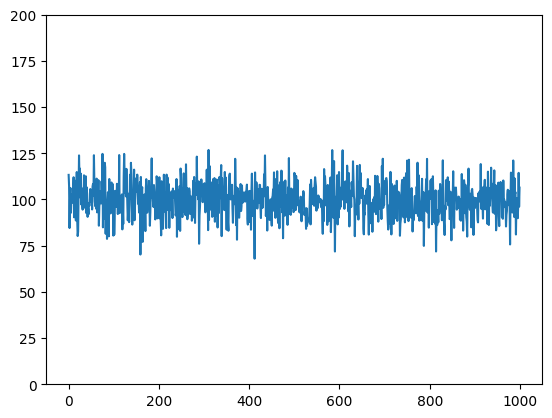

In [8]:
# get simple visualization
plt.plot(df.index, df['variable'])
plt.ylim([0, 200])
plt.show()

### Loading data from the CSV file

Call the `.load_data()` method for loading from CSV file:

In [9]:
# reset the uv variable
unv = Univar(name="Testing Univar", alias="uni-tst")

unv.load_data(
    file_data=file_csv,  # file path
    input_varfield="variable",  # name of column/field
    in_sep=";",  # input separator
)

Data is stored in the `.data` attribute as a `pandas.DataFrame`:

In [10]:
unv.data

,v
0,113.315865
1,107.152790
2,84.545997
3,99.916162
4,106.213360
...,...
995,89.856608
996,96.681723
997,114.406974
998,96.097821


### Access computed metadata

After loading data, some useful attributes are computed automatically.

Basic statistics are stored in `.stats_df` as a `pandas.DataFrame`:

In [11]:
unv.stats_df

,statistic,value
0,count,1000.000000
1,sum,99854.433644
2,mean,99.854434
3,sd,9.379578
4,min,67.955987
5,p01,78.678389
6,p05,84.521828
7,p10,87.959449
8,p20,92.072856
9,p25,93.609900


Data frequencies are stored in `.freq_df` as a `pandas.DataFrame`:


In [12]:
unv.freq_df

,Percentiles,Exceedance,Frequency,Empirical Probability,Values
0,0,100,1,0.001,67.955987
1,1,99,0,0.000,78.678389
2,2,98,0,0.000,80.584361
3,3,97,1,0.001,82.311344
4,4,96,0,0.000,83.409942
...,...,...,...,...,...
95,95,5,2,0.002,114.846091
96,96,4,2,0.002,116.115753
97,97,3,0,0.000,118.178726
98,98,2,0,0.000,120.658142


Data weibull CDF is stored in `.weibull_df` as a `pandas.DataFrame`:

In [13]:
unv.weibull_df

,Data,P(X),F(X)
0,126.799103,0.000999,0.999001
1,126.716851,0.001998,0.998002
2,126.625775,0.002997,0.997003
3,124.676511,0.003996,0.996004
4,124.653251,0.004995,0.995005
...,...,...,...
995,74.885309,0.995005,0.004995
996,71.849387,0.996004,0.003996
997,71.839988,0.997003,0.002997
998,70.204032,0.998002,0.001998


## Visualizations

Most `plans.` objects comes with built-in methods for getting visualizations, both inline and figure output.

```{seealso}
Check out more about visualizations on the {doc}`Visualizations - the basics <visuals_01>` tutorial.
```

### Standard visualization

Get the standard visual using the `.view()` method

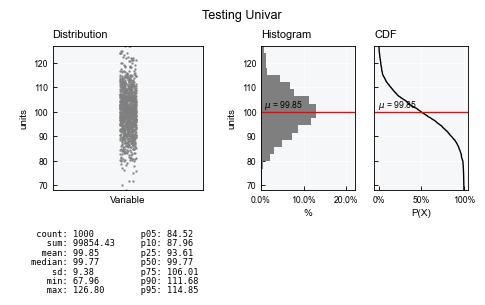

In [14]:
unv.view()

### Fine-tuning visuals

Use the `.view_specs` keys for fine tuning the visual. Example of some possibilities:

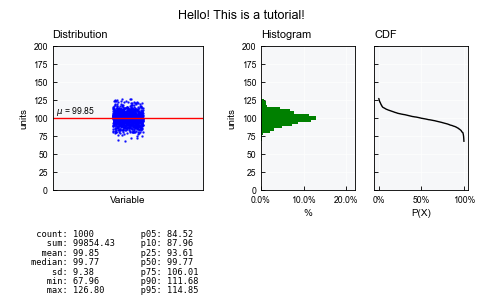

In [15]:
# Y axis range
unv.view_specs["range"] = [0, 200]
# Scatter
unv.view_specs["scatter_factor"] = 2 # occupy more space
# Color
unv.view_specs["color"] = "blue"
unv.view_specs["color_hist"] = "green"
# Decorations
unv.view_specs["plot_mean"] = False
unv.view_specs["plot_mean_data"] = True
unv.view_specs["title"] = "Hello! This is a tutorial!"
# call view again
unv.view()

### Layouts available

List available layout keys:

In [16]:
print(unv.layouts.keys())

dict_keys(['full', 'mini', 'simple', 'simple-shallow', 'default'])


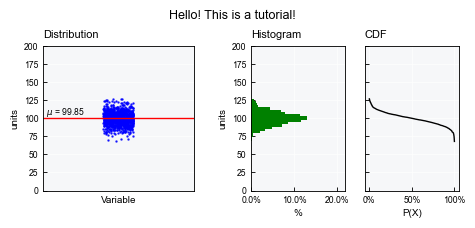

In [17]:
unv.view_specs["layout"] = "mini"
unv.view()

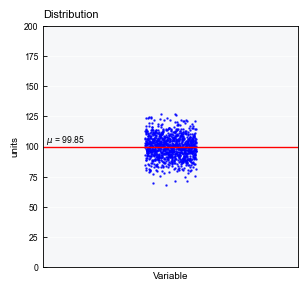

In [18]:
unv.view_specs["layout"] = "simple"
unv.view()

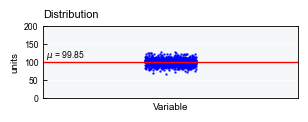

In [19]:
unv.view_specs["layout"] = "simple-shallow"
unv.view_specs["title"] = None
unv.view()

## Analysis methods

### Normality assessment

Assess if the data is normal via the `.get_normality()` method:

In [20]:
df = unv.get_normality(clevel=0.95)
df

,Test,Statistic,p-value,is_normal,Confidence
0,Kolmogorov-Smirnov,0.013838,0.989545,True,0.95
1,Shapiro-Wilk,0.998710,0.695039,True,0.95
2,D'Agostino-Pearson,0.477945,0.787436,True,0.95


### Weibull distribution

In [21]:
df = unv.get_cdf_weibull()
df

,Data,P(X),F(X)
0,126.799103,0.000999,0.999001
1,126.716851,0.001998,0.998002
2,126.625775,0.002997,0.997003
3,124.676511,0.003996,0.996004
4,124.653251,0.004995,0.995005
...,...,...,...
995,74.885309,0.995005,0.004995
996,71.849387,0.996004,0.003996
997,71.839988,0.997003,0.002997
998,70.204032,0.998002,0.001998


### Gumbel distribution

The method `.get_cdf_gumbel()` performs a full assessment for the Gumbel distribution.

```{warning}
This method assumes the data is a collection of maxima values.
```

In [22]:
dc_gumbel = unv.get_cdf_gumbel()

View model results:

In [23]:
df = dc_gumbel["Metadata"]
df

,Metadata,Value
0,N,1000
1,Gumbel a,95.633125
2,Gumbel b,7.313227
3,KS-test s-value,0.076734
4,KS-test p-value,0.000014
5,KS-test Is Gumbel (NullH),False
6,QQ-plot c0,2.405764
7,QQ plot c1,0.975998
8,QQ-plot r2,0.970525


View data:

In [24]:
df = dc_gumbel["Data"]
df

,v,Rank,P(X)_Empirical,P(X)_Weibull,T(X)_Weibull,P(X)_Gringorten,P(X)_Gumbel,T(X)_Gumbel,T(X)_Gumbel_SE90,T(X)_Gumbel_P05,T(X)_Gumbel_P95
0,126.799103,1,0.001,0.000999,1001.000000,0.000560,0.014001,71.423884,1.784416,56.068652,91.022575
1,126.716851,2,0.002,0.001998,500.500000,0.001560,0.014158,70.630695,1.780045,55.480053,89.956708
2,126.625775,3,0.003,0.002997,333.666667,0.002560,0.014334,69.762759,1.775206,54.835575,88.791140
3,124.676511,4,0.004,0.003996,250.250000,0.003560,0.018671,53.557703,1.671825,42.715790,67.184470
4,124.653251,5,0.005,0.004995,200.200000,0.004559,0.018730,53.389231,1.670594,42.588833,66.961535
...,...,...,...,...,...,...,...,...,...,...,...
995,74.885309,996,0.996,0.995005,1.005020,0.995441,1.000000,1.000000,1.172041,1.000000,1.000000
996,71.849387,997,0.997,0.996004,1.004012,0.996440,1.000000,1.000000,1.328611,1.000000,1.000000
997,71.839988,998,0.998,0.997003,1.003006,0.997440,1.000000,1.000000,1.329099,1.000000,1.000000
998,70.204032,999,0.999,0.998002,1.002002,0.998440,1.000000,1.000000,1.414199,1.000000,1.000000


View return periods T(X):

In [25]:
df =dc_gumbel["Data_T(X)"]
df

,T(X)_Gumbel,v,v_P25,v_P75,v_P05,v_P95
0,2,98.313631,98.129944,98.497319,97.865427,98.761836
1,3,102.235039,102.001629,102.468448,101.665511,102.804566
2,4,104.744783,104.469400,105.020167,104.072837,105.416730
3,5,106.602640,106.293272,106.912009,105.847769,107.357511
4,6,108.080229,107.742617,108.417842,107.256442,108.904016
...,...,...,...,...,...,...
994,996,146.118235,144.961888,147.274581,143.296704,148.939765
995,997,146.125577,144.969068,147.282087,143.303650,148.947505
996,998,146.132913,144.976241,147.289584,143.310589,148.955236
997,999,146.140240,144.983406,147.297074,143.317521,148.962960
